<a href="https://colab.research.google.com/github/harpreetsingh171190-cmyk/sea-level-predictor/blob/main/sea_level_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<Axes: title={'center': 'Rise in Sea Level'}, xlabel='Year', ylabel='Sea Level (inches)'>

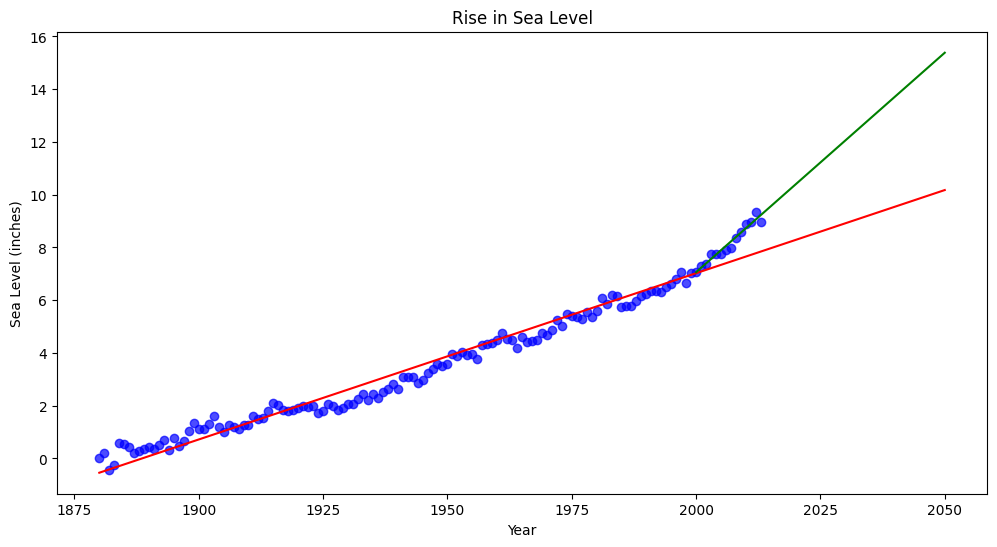

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import linregress

# 1. डेटा को सबसे पहले लोड करें
df = pd.read_csv(
    'https://raw.githubusercontent.com/freeCodeCamp/boilerplate-sea-level-predictor/master/epa-sea-level.csv'
)


def draw_plot():
  # 2. Create scatter plot
  fig, ax = plt.subplots(figsize=(12, 6))
  ax.scatter(
      df['Year'], df['CSIRO Adjusted Sea Level'], color='blue', alpha=0.7
  )

  # 3. Create first line of best fit (1880 - 2014)
  res = linregress(df['Year'], df['CSIRO Adjusted Sea Level'])
  x_pred = pd.Series(range(df['Year'].min(), 2051))
  y_pred = res.slope * x_pred + res.intercept
  ax.plot(
      x_pred,
      y_pred,
      'r',
      label='Best Fit Line (1880-2014)',
  )

  # 4. Create second line of best fit (2000 onwards)
  df_recent = df[df['Year'] >= 2000]
  res_recent = linregress(
      df_recent['Year'], df_recent['CSIRO Adjusted Sea Level']
  )
  x_pred_recent = pd.Series(range(2000, 2051))
  y_pred_recent = res_recent.slope * x_pred_recent + res_recent.intercept
  ax.plot(
      x_pred_recent,
      y_pred_recent,
      'green',
      label='Best Fit Line (2000-2014)',
  )

  # 5. Add labels and title
  ax.set_xlabel('Year')
  ax.set_ylabel('Sea Level (inches)')
  ax.set_title('Rise in Sea Level')

  plt.savefig('sea_level_plot.png')
  return plt.gca()


# फलन को यहाँ कॉल करें
draw_plot()